# DCGAN vs WGAN-GP — Tackling Mode Collapse in GANs
**Course:** Generative AI (AI4009) | **Assignment:** No. 2 | **Semester:** Spring 2026

---
# 1. ENVIRONMENT SETUP

In [1]:
!pip install gradio --quiet

In [2]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm

In [24]:
# ── Config ────────────────────────────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE   = 64
Z_DIM        = 100
CHANNELS     = 3
FEATURES_G   = 64
FEATURES_D   = 64

BATCH_SIZE   = 64
LR           = 0.0002
BETAS        = (0.5, 0.999)

DCGAN_EPOCHS = 15
WGAN_EPOCHS  = 15
CRITIC_ITERS = 5
LAMBDA_GP    = 10

CKPT_DIR     = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

Device: cuda


---
# 2. DATA PREPARATION

In [25]:
import kagglehub


data_path = kagglehub.dataset_download("soumikrakshit/anime-faces")
print("Dataset path:", data_path)

Using Colab cache for faster access to the 'anime-faces' dataset.
Dataset path: /kaggle/input/anime-faces


In [26]:

img_dir = None
for root, dirs, files in os.walk(data_path):
    jpgs = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if len(jpgs) > 100:

        img_dir = str(Path(root).parent)
        break

print("Image folder:", img_dir)

Image folder: /kaggle/input/anime-faces


In [27]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
])

dataset    = ImageFolder(img_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)

print(f"Dataset: {len(dataset)} images | Batches: {len(dataloader)}")

Dataset: 43102 images | Batches: 673


---
# 3. MODEL ARCHITECTURE
## Helper — weight initialisation

In [28]:
def weights_init(m):
    """Apply Xavier-style init to Conv and BatchNorm layers."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

## Generator (shared by DCGAN and WGAN-GP)

In [29]:
class Generator(nn.Module):
    """z (100,1,1) → image (3,64,64) via transposed convolutions."""
    def __init__(self):
        super().__init__()
        f = FEATURES_G
        self.net = nn.Sequential(

            nn.ConvTranspose2d(Z_DIM,  f*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(f*8), nn.ReLU(True),

            nn.ConvTranspose2d(f*8, f*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f*4), nn.ReLU(True),

            nn.ConvTranspose2d(f*4, f*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f*2), nn.ReLU(True),

            nn.ConvTranspose2d(f*2,   f, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f),   nn.ReLU(True),

            nn.ConvTranspose2d(f, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

## DCGAN Discriminator (with Sigmoid)

In [30]:
class DCGANDiscriminator(nn.Module):
    """image (3,64,64) → real/fake probability."""
    def __init__(self):
        super().__init__()
        f = FEATURES_D
        self.net = nn.Sequential(

            nn.Conv2d(CHANNELS,   f, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(f,   f*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f*2), nn.LeakyReLU(0.2, True),

            nn.Conv2d(f*2, f*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f*4), nn.LeakyReLU(0.2, True),

            nn.Conv2d(f*4, f*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(f*8), nn.LeakyReLU(0.2, True),

            nn.Conv2d(f*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)

## WGAN-GP Critic (no Sigmoid, uses InstanceNorm)

In [31]:
class WGANCritic(nn.Module):
    """image (3,64,64) → scalar score (no sigmoid)."""
    def __init__(self):
        super().__init__()
        f = FEATURES_D
        self.net = nn.Sequential(
            nn.Conv2d(CHANNELS,   f, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(f,   f*2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(f*2, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*2, f*4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(f*4, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*4, f*8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(f*8, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(f*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)

## Gradient Penalty (WGAN-GP)

In [32]:
def gradient_penalty(critic, real, fake):
    B = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score = critic(interpolated)
    grad  = torch.autograd.grad(
        outputs=score, inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True
    )[0]
    gp = ((grad.view(B, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp

## Initialise Models

In [33]:
# DCGAN
dcgan_G = Generator().to(device).apply(weights_init)
dcgan_D = DCGANDiscriminator().to(device).apply(weights_init)

# WGAN-GP (fresh generator)
wgan_G  = Generator().to(device).apply(weights_init)
wgan_C  = WGANCritic().to(device).apply(weights_init)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"Generator params   : {count_params(dcgan_G):,}")
print(f"Discriminator params: {count_params(dcgan_D):,}")
print(f"Critic params       : {count_params(wgan_C):,}")

Generator params   : 3,576,704
Discriminator params: 2,765,568
Critic params       : 2,765,568


---
# 4. TRAINING
## 4a — DCGAN

In [34]:
criterion = nn.BCEWithLogitsLoss()

opt_dcgan_G = torch.optim.Adam(dcgan_G.parameters(), lr=LR, betas=BETAS)
opt_dcgan_D = torch.optim.Adam(dcgan_D.parameters(), lr=LR, betas=BETAS)

scaler = torch.amp.GradScaler("cuda")

# Fixed noise for visualisation consistency
fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

dcgan_G_losses, dcgan_D_losses = [], []

for epoch in range(1, DCGAN_EPOCHS + 1):
    dcgan_G.train(); dcgan_D.train()
    g_ep, d_ep = 0.0, 0.0

    for real, _ in tqdm(dataloader, desc=f"DCGAN {epoch}/{DCGAN_EPOCHS}"):
        real = real.to(device, non_blocking=True)
        B    = real.size(0)

        # Train Discriminator
        opt_dcgan_D.zero_grad()
        with torch.amp.autocast("cuda"):
            real_labels = torch.ones(B,  device=device)
            fake_labels = torch.zeros(B, device=device)
            z    = torch.randn(B, Z_DIM, 1, 1, device=device)
            fake = dcgan_G(z).detach()
            d_loss = (criterion(dcgan_D(real), real_labels) +
                      criterion(dcgan_D(fake), fake_labels))
        scaler.scale(d_loss).backward()
        scaler.step(opt_dcgan_D)
        scaler.update()

        # Train Generator
        opt_dcgan_G.zero_grad()
        with torch.amp.autocast("cuda"):
            z    = torch.randn(B, Z_DIM, 1, 1, device=device)
            fake = dcgan_G(z)
            g_loss = criterion(dcgan_D(fake), torch.ones(B, device=device))
        scaler.scale(g_loss).backward()
        scaler.step(opt_dcgan_G)
        scaler.update()

        g_ep += g_loss.item()
        d_ep += d_loss.item()

    g_ep /= len(dataloader); d_ep /= len(dataloader)
    dcgan_G_losses.append(g_ep)
    dcgan_D_losses.append(d_ep)
    print(f"DCGAN Epoch {epoch}/{DCGAN_EPOCHS}  G={g_ep:.4f}  D={d_ep:.4f}")


    if epoch % 5 == 0:
        torch.save(dcgan_G.state_dict(), f"{CKPT_DIR}/dcgan_G_ep{epoch}.pt")

print("DCGAN training complete!")

DCGAN 1/15: 100%|██████████| 673/673 [01:32<00:00,  7.31it/s]


DCGAN Epoch 1/15  G=7.4442  D=0.7448


DCGAN 2/15: 100%|██████████| 673/673 [00:42<00:00, 15.72it/s]


DCGAN Epoch 2/15  G=6.0948  D=0.5605


DCGAN 3/15: 100%|██████████| 673/673 [00:42<00:00, 15.77it/s]


...

DCGAN Epoch 13/15  G=3.9871  D=0.3986


DCGAN 14/15: 100%|██████████| 673/673 [00:42<00:00, 15.76it/s]


DCGAN Epoch 14/15  G=4.0099  D=0.3496


DCGAN 15/15: 100%|██████████| 673/673 [00:43<00:00, 15.54it/s]

DCGAN Epoch 15/15  G=4.0132  D=0.4025
DCGAN training complete!


## 4b — WGAN-GP

In [35]:
opt_wgan_G = torch.optim.Adam(wgan_G.parameters(), lr=LR, betas=BETAS)
opt_wgan_C = torch.optim.Adam(wgan_C.parameters(), lr=LR, betas=BETAS)

wgan_G_losses, wgan_C_losses = [], []

for epoch in range(1, WGAN_EPOCHS + 1):
    wgan_G.train(); wgan_C.train()
    g_ep, c_ep = 0.0, 0.0
    g_count = 0

    for i, (real, _) in enumerate(tqdm(dataloader, desc=f"WGAN-GP {epoch}/{WGAN_EPOCHS}")):
        real = real.to(device, non_blocking=True)
        B    = real.size(0)

        # Train Critic (CRITIC_ITERS times per G update)
        opt_wgan_C.zero_grad()
        z    = torch.randn(B, Z_DIM, 1, 1, device=device)
        fake = wgan_G(z).detach()
        gp   = gradient_penalty(wgan_C, real, fake)
        c_loss = -(wgan_C(real).mean() - wgan_C(fake).mean()) + LAMBDA_GP * gp
        c_loss.backward()
        opt_wgan_C.step()
        c_ep += c_loss.item()

        # Train Generator (every CRITIC_ITERS steps)
        if i % CRITIC_ITERS == 0:
            opt_wgan_G.zero_grad()
            z    = torch.randn(B, Z_DIM, 1, 1, device=device)
            fake = wgan_G(z)
            g_loss = -wgan_C(fake).mean()
            g_loss.backward()
            opt_wgan_G.step()
            g_ep += g_loss.item()
            g_count += 1

    g_ep /= max(g_count, 1); c_ep /= len(dataloader)
    wgan_G_losses.append(g_ep)
    wgan_C_losses.append(c_ep)
    print(f"WGAN-GP Epoch {epoch}/{WGAN_EPOCHS}  G={g_ep:.4f}  C={c_ep:.4f}")

    if epoch % 5 == 0:
        torch.save(wgan_G.state_dict(), f"{CKPT_DIR}/wgan_G_ep{epoch}.pt")

print("WGAN-GP training complete!")

WGAN-GP 1/15: 100%|██████████| 673/673 [01:25<00:00,  7.91it/s]


WGAN-GP Epoch 1/15  G=7.8804  C=-11.3075


WGAN-GP 2/15: 100%|██████████| 673/673 [01:25<00:00,  7.90it/s]


WGAN-GP Epoch 2/15  G=20.8734  C=-21.3179


WGAN-GP 3/15: 100%|██████████| 673/673 [01:24<00:00,  7.93it/s]


...

WGAN-GP Epoch 13/15  G=27.4898  C=-14.1457


WGAN-GP 14/15: 100%|██████████| 673/673 [01:24<00:00,  7.92it/s]


WGAN-GP Epoch 14/15  G=27.5165  C=-13.7008


WGAN-GP 15/15: 100%|██████████| 673/673 [01:25<00:00,  7.91it/s]

WGAN-GP Epoch 15/15  G=27.1660  C=-13.3105
WGAN-GP training complete!


---
# 5. TRAINING LOSS PLOTS

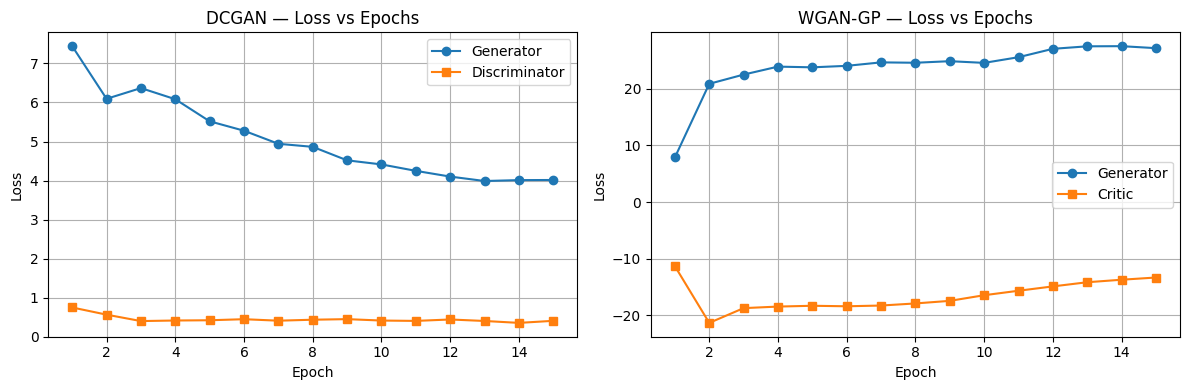

In [36]:
epochs = range(1, DCGAN_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dcgan_G_losses, label='Generator',     marker='o')
axes[0].plot(epochs, dcgan_D_losses, label='Discriminator', marker='s')
axes[0].set_title('DCGAN — Loss vs Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

wepochs = range(1, WGAN_EPOCHS + 1)
axes[1].plot(wepochs, wgan_G_losses, label='Generator', marker='o')
axes[1].plot(wepochs, wgan_C_losses, label='Critic',    marker='s')
axes[1].set_title('WGAN-GP — Loss vs Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

---
# 6. VISUALIZATION MODULE
## Helper

In [37]:
@torch.no_grad()
def show_samples(G, title, n=16, seed=42):
    G.eval()
    torch.manual_seed(seed)
    z    = torch.randn(n, Z_DIM, 1, 1, device=device)
    imgs = G(z).cpu()
    grid = vutils.make_grid(imgs, nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

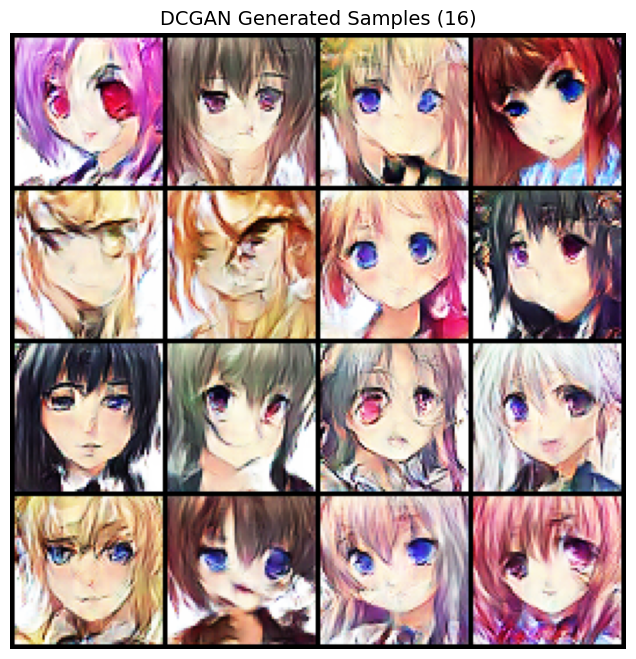

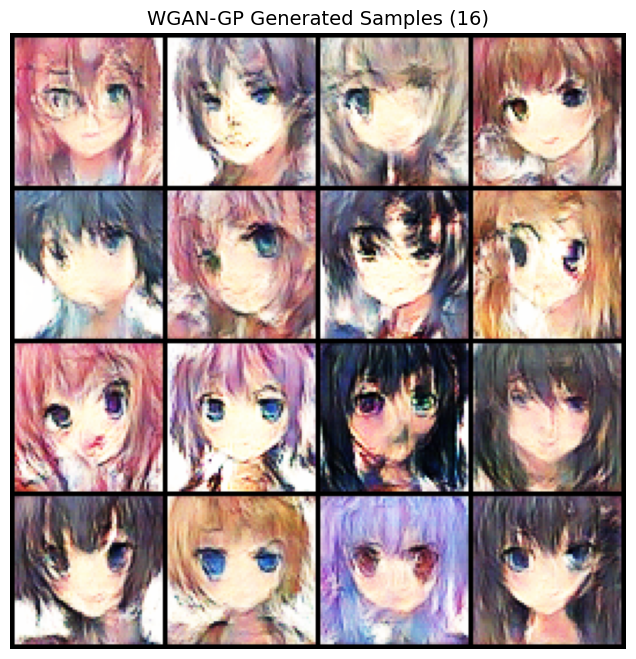

In [38]:

show_samples(dcgan_G, "DCGAN Generated Samples (16)", n=16)
show_samples(wgan_G,  "WGAN-GP Generated Samples (16)", n=16)

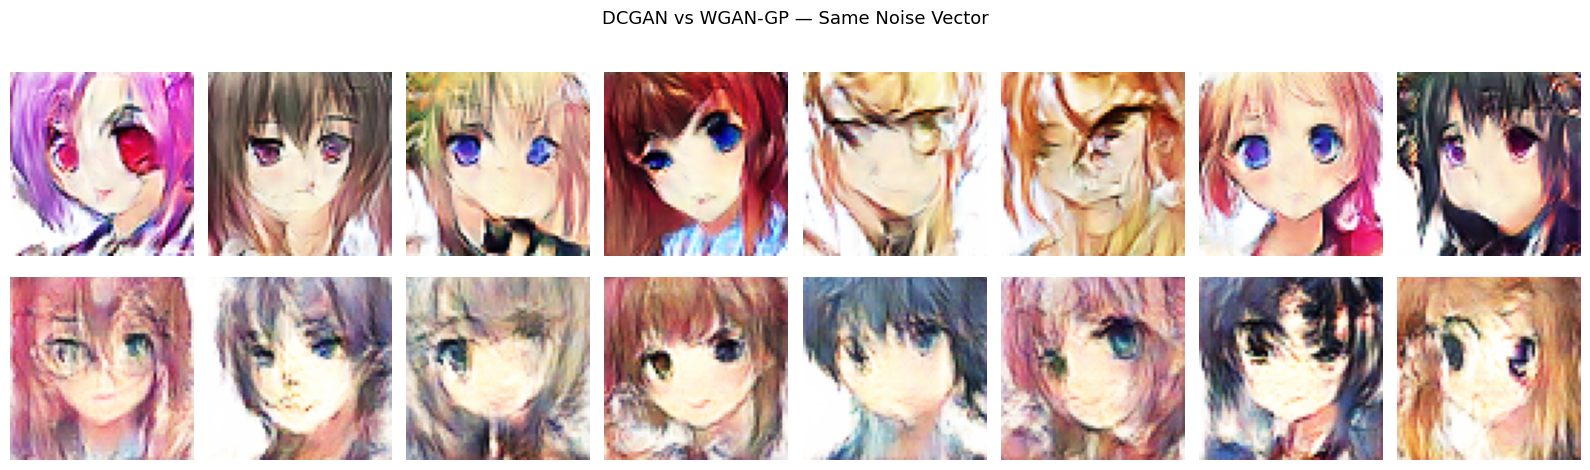

In [39]:

@torch.no_grad()
def compare_models(n=8, seed=42):
    torch.manual_seed(seed)
    z    = torch.randn(n, Z_DIM, 1, 1, device=device)
    dcgan_imgs = dcgan_G(z).cpu()
    wgan_imgs  = wgan_G(z).cpu()

    fig, axes = plt.subplots(2, n, figsize=(2*n, 5))
    for i in range(n):
        for j, (imgs, lbl) in enumerate([(dcgan_imgs, 'DCGAN'), (wgan_imgs, 'WGAN-GP')]):
            img = imgs[i].permute(1, 2, 0).clamp(-1, 1).numpy()
            img = (img + 1) / 2
            axes[j, i].imshow(img)
            axes[j, i].axis('off')
            if i == 0:
                axes[j, i].set_ylabel(lbl, fontsize=11)
    plt.suptitle("DCGAN vs WGAN-GP — Same Noise Vector", fontsize=13)
    plt.tight_layout()
    plt.show()

compare_models(n=8)

---
# 7. SAVE FINAL MODELS

In [40]:
torch.save(dcgan_G.state_dict(), f"{CKPT_DIR}/dcgan_G_final.pt")
torch.save(dcgan_D.state_dict(), f"{CKPT_DIR}/dcgan_D_final.pt")
torch.save(wgan_G.state_dict(),  f"{CKPT_DIR}/wgan_G_final.pt")
torch.save(wgan_C.state_dict(),  f"{CKPT_DIR}/wgan_C_final.pt")

with open(f"{CKPT_DIR}/losses.json", 'w') as f:
    json.dump({
        'dcgan_G': dcgan_G_losses, 'dcgan_D': dcgan_D_losses,
        'wgan_G':  wgan_G_losses,  'wgan_C':  wgan_C_losses
    }, f, indent=2)

print("Models and losses saved!")

Models and losses saved!


---
# 8. GRADIO APP

In [43]:
import gradio as gr

dcgan_G.eval(); wgan_G.eval()


def tensor_to_pil(t):
    """CHW tensor [-1,1] → PIL Image."""
    arr = ((t.permute(1, 2, 0).numpy() + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(arr)


@torch.no_grad()
def make_grid_pil(G, n, seed):
    torch.manual_seed(int(seed))
    z    = torch.randn(int(n), Z_DIM, 1, 1, device=device)
    imgs = G(z).cpu()
    grid = vutils.make_grid(imgs, nrow=4, normalize=True, value_range=(-1, 1))
    return tensor_to_pil(grid)


def compare(n, seed):
    return make_grid_pil(dcgan_G, n, seed), make_grid_pil(wgan_G, n, seed)


def single(model_name, n, seed):
    G = dcgan_G if model_name == 'DCGAN' else wgan_G
    return make_grid_pil(G, n, seed)


with gr.Blocks(title="GAN Demo") as demo:
    gr.Markdown("# DCGAN vs WGAN-GP — Anime Face Generation\nCompare how Wasserstein Loss + Gradient Penalty reduces mode collapse.")

    with gr.Tab("Side-by-Side Comparison"):
        with gr.Row():
            seed_s = gr.Slider(0, 9999, value=42, step=1, label="Seed")
            n_s    = gr.Slider(4, 16,   value=16, step=4, label="Samples")
            btn    = gr.Button("Generate", variant="primary")
        with gr.Row():
            out_d  = gr.Image(label="DCGAN (BCE Loss)",         type="pil")
            out_w  = gr.Image(label="WGAN-GP (Wasserstein+GP)", type="pil")
        btn.click(compare, [n_s, seed_s], [out_d, out_w])

    with gr.Tab("Single Model"):
        with gr.Row():
            m_r    = gr.Radio(['DCGAN', 'WGAN-GP'], value='WGAN-GP', label="Model")
            seed_r = gr.Slider(0, 9999, value=0,  step=1, label="Seed")
            n_r    = gr.Slider(4, 16,   value=16, step=4, label="Samples")
            btn2   = gr.Button("Generate", variant="primary")
        out_s = gr.Image(label="Output", type="pil")
        btn2.click(single, [m_r, n_r, seed_r], out_s)

    with gr.Tab("Model Info"):
        gr.Markdown(f"""
        ## Architecture Summary
        | | DCGAN | WGAN-GP |
        |---|---|---|
        | **Discriminator/Critic** | Conv + BatchNorm + Sigmoid | Conv + InstanceNorm (no sigmoid) |
        | **Loss** | Binary Cross Entropy | Wasserstein Distance |
        | **Gradient constraint** | None | Gradient Penalty (λ={LAMBDA_GP}) |
        | **Critic updates / G update** | 1 | {CRITIC_ITERS} |

        ## Why WGAN-GP beats DCGAN
        - **BCE loss saturates** when discriminator is too confident → vanishing gradients → mode collapse
        - **Wasserstein distance** always gives a meaningful gradient signal
        - **Gradient Penalty** enforces 1-Lipschitz constraint for stable critic training
        """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47fcf665d5db9950e8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
